<a href="https://colab.research.google.com/github/sam-wahid/vlm-llm-segmentation/blob/main/sigLIPbenchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers
!pip install -q torch torchvision
!pip install -q scikit-learn tqdm matplotlib

In [2]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from transformers import AutoModel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [4]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor()
])

dataset = datasets.FashionMNIST(

    root="./data",
    train=False,
    download=True,
    transform=transform
)

loader = DataLoader(

    dataset,
    batch_size=32,
    shuffle=False
)

print("Total Images:", len(dataset))

print("Classes:", dataset.classes)

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.4MB/s]

Total Images: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
siglip_model = AutoModel.from_pretrained(

    "google/siglip-base-patch16-224"
).vision_model.to(device)

siglip_model.eval()

print("SigLIP Vision Model Loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP Vision Model Loaded


In [6]:
def benchmark_siglip_model(model, loader):

    embeddings = []
    all_labels = []

    total_time = 0
    total_images = 0

    # Reset GPU memory stats
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            # Start timer
            start = time.time()

            # Forward pass
            outputs = model(pixel_values=images)

            # Extract pooled embeddings
            features = outputs.pooler_output

            # End timer
            end = time.time()

            # Time calculation
            total_time += (end - start)

            total_images += images.size(0)

            # Convert to numpy
            features = features.cpu().numpy()

            embeddings.append(features)

            all_labels.append(labels.numpy())

    # Merge batches
    embeddings = np.concatenate(embeddings, axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    # FPS
    fps = total_images / total_time

    # Latency
    latency = total_time / total_images

    # GPU memory
    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.max_memory_allocated() / 1024**3
        )

    else:
        gpu_memory = 0

    return {

        "embeddings": embeddings,
        "labels": all_labels,
        "fps": fps,
        "latency": latency,
        "gpu_memory": gpu_memory
    }

In [7]:
def benchmark_siglip_model(model, loader):

    embeddings = []
    all_labels = []

    total_time = 0
    total_images = 0

    # Reset GPU memory stats
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            # Start timer
            start = time.time()

            # Forward pass
            outputs = model(pixel_values=images)

            # Extract pooled embeddings
            features = outputs.pooler_output

            # End timer
            end = time.time()

            # Time calculation
            total_time += (end - start)

            total_images += images.size(0)

            # Convert to numpy
            features = features.cpu().numpy()

            embeddings.append(features)

            all_labels.append(labels.numpy())

    # Merge batches
    embeddings = np.concatenate(embeddings, axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    # FPS
    fps = total_images / total_time

    # Latency
    latency = total_time / total_images

    # GPU memory
    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.max_memory_allocated() / 1024**3
        )

    else:
        gpu_memory = 0

    return {

        "embeddings": embeddings,
        "labels": all_labels,
        "fps": fps,
        "latency": latency,
        "gpu_memory": gpu_memory
    }

In [8]:
siglip_results = benchmark_siglip_model(

    siglip_model,
    loader
)

100%|██████████| 313/313 [1:50:08<00:00, 21.11s/it]


In [9]:
X = siglip_results["embeddings"]

y = siglip_results["labels"]

# 80% train / 20% test split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# kNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

In [10]:
print("\n========== SigLIP FINAL RESULTS ==========")

print("Accuracy      :", round(accuracy * 100, 2), "%")

print("FPS           :", round(siglip_results["fps"], 2))

print("Latency       :", round(siglip_results["latency"], 5))

print("GPU Memory GB :", round(siglip_results["gpu_memory"], 2))


========== SigLIP FINAL RESULTS ==========
Accuracy      : 89.1 %
FPS           : 1.52
Latency       : 0.6594
GPU Memory GB : 0


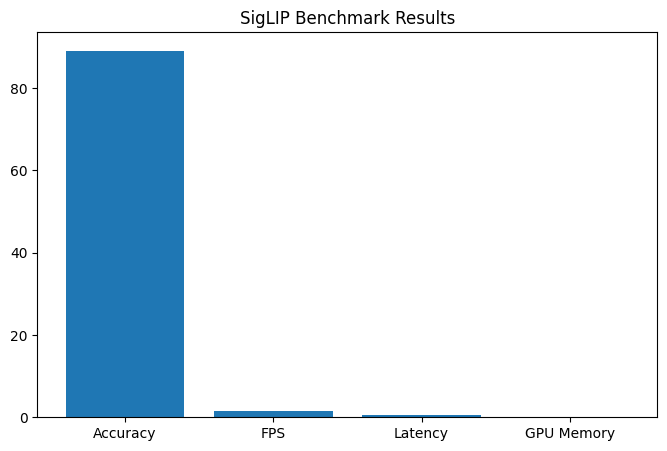

In [11]:
metrics = [

    round(accuracy * 100, 2),

    round(siglip_results["fps"], 2),

    round(siglip_results["latency"], 5),

    round(siglip_results["gpu_memory"], 2)
]

metric_names = [

    "Accuracy",
    "FPS",
    "Latency",
    "GPU Memory"
]

plt.figure(figsize=(8,5))

plt.bar(metric_names, metrics)

plt.title("SigLIP Benchmark Results")

plt.show()